<a href="https://colab.research.google.com/github/pixel2306/Thesis_FR-TVCM/blob/main/TVLM%5B1%2C7%2C8%2C14%2C15%5D_%2B_LN_tk%5BEPA%5D_bw%5B0_085%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LIBRARY**

In [ ]:
install.packages("fda")
install.packages("tvReg")
install.packages("readxl")
install.packages("tidyverse")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("patchwork")
install.packages("latex2exp")
install.packages("gridExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mvtnorm’, ‘locfit’, ‘ash’, ‘FNN’, ‘kernlab’, ‘mclust’, ‘multicool’, ‘pracma’, ‘pcaPP’, ‘hdrcde’, ‘colorspace’, ‘ks’, ‘bitops’, ‘rainbow’, ‘RCurl’, ‘fds’, ‘deSolve’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘fracdiff’, ‘timeDate’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘miscTools’, ‘rbibutils’, ‘car’, ‘lmtest’, ‘sandwich’, ‘strucchange’, ‘urca’, ‘RcppArmadillo’, ‘bdsmatrix’, ‘collapse’, ‘zoo’, ‘maxLik’, ‘Rdpack’, ‘Formula’, ‘systemfit’, ‘vars’, ‘bvarsv’, ‘plm’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package 

In [ ]:
library(fda)
library(tvReg)
library(readxl)
library(fda)
library(dplyr)
library(tidyverse)
library(ggplot2)
library(patchwork)
library(latex2exp)
library(gridExtra)

Loading required package: splines

Loading required package: fds

Loading required package: rainbow

Loading required package: MASS

Loading required package: pcaPP

Loading required package: RCurl

Loading required package: deSolve


Attaching package: ‘fda’


The following object is masked from ‘package:graphics’:

    matplot


The following object is masked from ‘package:datasets’:

    gait


Loading required package: Matrix

Funded by the Horizon 2020. Framework Programme of the European Union.



Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ 

**DATA**

In [ ]:
data <- read_excel("BKJP REAL.xlsx")
head(data)

No,Tanggal,Waktu,Y,Hari,DM,LN,LNADJ,NEWLN,WE,DS,DMLN
<dbl>,<dttm>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2020-01-01,00.30,3602.309,Rabu,0,1,1,1,0,0,1
2,2020-01-01,01.00,3525.583,Rabu,0,1,1,1,0,0,1
3,2020-01-01,01.30,3465.264,Rabu,0,1,1,1,0,0,1
4,2020-01-01,02.00,3400.974,Rabu,0,1,1,1,0,0,1
5,2020-01-01,02.30,3368.715,Rabu,0,1,1,1,0,0,1
6,2020-01-01,03.00,3326.610,Rabu,0,1,1,1,0,0,1


**FR-TVCM Modeling**

In [ ]:
Y <- data$Y[721:87648]
Ylag1 <- data$Y[673:87600]
Ylag2 <- data$Y[625:87552]
Ylag3 <- data$Y[577:87504]
Ylag4 <- data$Y[529:87456]
Ylag5 <- data$Y[481:87408]
Ylag6 <- data$Y[433:87360]
Ylag7 <- data$Y[385:87312]
Ylag8 <- data$Y[337:87264]
Ylag9 <- data$Y[289:87216]
Ylag10 <- data$Y[241:87168]
Ylag11 <- data$Y[193:87120]
Ylag12 <- data$Y[145:87072]
Ylag13 <- data$Y[97:87024]
Ylag14 <- data$Y[49:86976]
Ylag15 <- data$Y[1:86928]

LN <- data$NEWLN[721:87648]

n_day <- 1811
intervals_per_day <- 48
n <- n_day * intervals_per_day

# Slot waktu dalam sehari (1 sampai 48), diulang untuk 30 hari
slot <- rep(1:intervals_per_day, n_day)
slot_scaled <- (slot - 1) / (intervals_per_day - 1)

# Model tvLM
Model_tvLM1 <- tvLM(Y ~ 1 + Ylag1 + Ylag7 + Ylag8 + Ylag14 + Ylag15 + LN,
                   z = slot_scaled, bw = 0.085, tkernel = "Epa",
                   est = "ll")
summary(Model_tvLM1)


Call: 
tvLM(formula = Y ~ 1 + Ylag1 + Ylag7 + Ylag8 + Ylag14 + Ylag15 + 
    LN, z = slot_scaled, bw = 0.085, est = "ll", tkernel = "Epa")

Class:  tvlm 

Summary of time-varying estimated coefficients: 
        (Intercept)  Ylag1  Ylag7   Ylag8 Ylag14  Ylag15     LN
Min.          209.6 0.5003 0.4299 -0.3801 0.3749 -0.2700 -829.9
1st Qu.       276.3 0.5127 0.4373 -0.3496 0.3839 -0.2383 -768.4
Median        377.0 0.6369 0.4504 -0.3231 0.3886 -0.2131 -407.2
Mean          385.8 0.6267 0.4540 -0.3269 0.3884 -0.2128 -497.8
3rd Qu.       519.6 0.7039 0.4702 -0.2921 0.3918 -0.1815 -306.2
Max.          590.5 0.7728 0.4802 -0.2835 0.4017 -0.1679 -210.7

Bandwidth:  0.085
Pseudo R-squared:  0.9054 



**CI 95%**

In [ ]:
CI95_M1 <- confint(Model_tvLM1, level = 0.95, runs = 10)
summary(CI95_M1)


Call: 
tvLM(formula = Y ~ 1 + Ylag1 + Ylag7 + Ylag8 + Ylag14 + Ylag15 + 
    LN, z = slot_scaled, bw = 0.085, est = "ll", tkernel = "Epa")

Class:  tvlm 

Summary of time-varying estimated coefficients: 
        (Intercept)  Ylag1  Ylag7   Ylag8 Ylag14  Ylag15     LN
Min.          209.6 0.5003 0.4299 -0.3801 0.3749 -0.2700 -829.9
1st Qu.       276.3 0.5127 0.4373 -0.3496 0.3839 -0.2383 -768.4
Median        377.0 0.6369 0.4504 -0.3231 0.3886 -0.2131 -407.2
Mean          385.8 0.6267 0.4540 -0.3269 0.3884 -0.2128 -497.8
3rd Qu.       519.6 0.7039 0.4702 -0.2921 0.3918 -0.1815 -306.2
Max.          590.5 0.7728 0.4802 -0.2835 0.4017 -0.1679 -210.7

LOWER (95%) confidence interval: 
        (Intercept)  Ylag1  Ylag7   Ylag8 Ylag14  Ylag15     LN
Min.          159.9 0.4789 0.3785 -0.4304 0.3330 -0.3046 -891.3
1st Qu.       241.1 0.4961 0.4133 -0.3814 0.3579 -0.2672 -801.8
Median        331.5 0.6202 0.4303 -0.3398 0.3644 -0.2338 -441.6
Mean          345.2 0.6076 0.4286 -0.3488 0.3646 -0.2342

In [ ]:
CI95_M1$Lower[1:48,]

(Intercept),Ylag1,Ylag7,Ylag8,Ylag14,Ylag15,LN
159.8665,0.7332477,0.3784770,-0.4304418,0.3641148,-0.3046314,-243.6718
183.8715,0.7457013,0.3972979,-0.4104704,0.3798361,-0.2886871,-234.7673
175.1894,0.7512445,0.4133459,-0.4004561,0.3865902,-0.2870089,-228.2228
175.0756,0.7525223,0.4138369,-0.3956544,0.3879699,-0.2891070,-224.9179
176.9159,0.7539403,0.4118297,-0.4021686,0.3856312,-0.2920634,-227.4434
181.6710,0.7555220,0.4105624,-0.4075320,0.3825422,-0.2942866,-234.9469
183.3459,0.7563695,0.4088213,-0.4076145,0.3821416,-0.2903161,-244.7213
190.2553,0.7552709,0.4130007,-0.4020693,0.3865923,-0.2889112,-253.2653
195.9788,0.7479376,0.4148238,-0.3934296,0.3792526,-0.2902975,-268.3425
205.7478,0.7360389,0.4123970,-0.3877428,0.3735531,-0.2867354,-290.4384


In [ ]:
CI95_M1$Upper[1:48,]

(Intercept),Ylag1,Ylag7,Ylag8,Ylag14,Ylag15,LN
305.2783,0.7892335,0.4813236,-0.3116906,0.4345252,-0.2282119,-177.6672
275.6709,0.7802378,0.4643139,-0.3350484,0.4207884,-0.2475582,-190.5588
276.6184,0.7799234,0.4496783,-0.3505641,0.4153326,-0.2507065,-200.1574
267.1078,0.7852151,0.4489317,-0.3595079,0.4149687,-0.2502829,-206.3911
253.1468,0.7896566,0.4507867,-0.3561565,0.4177259,-0.2479598,-209.0539
237.7796,0.7899883,0.4528387,-0.3527415,0.4202342,-0.2434996,-210.1330
235.9470,0.7851765,0.4553570,-0.3518112,0.4191689,-0.2430935,-212.9080
241.5129,0.7789256,0.4504059,-0.3534293,0.4153592,-0.2427341,-221.8883
248.2206,0.7781231,0.4493051,-0.3582585,0.4230395,-0.2399017,-230.4658
261.6428,0.7738097,0.4531343,-0.3570898,0.4259498,-0.2371611,-243.0711


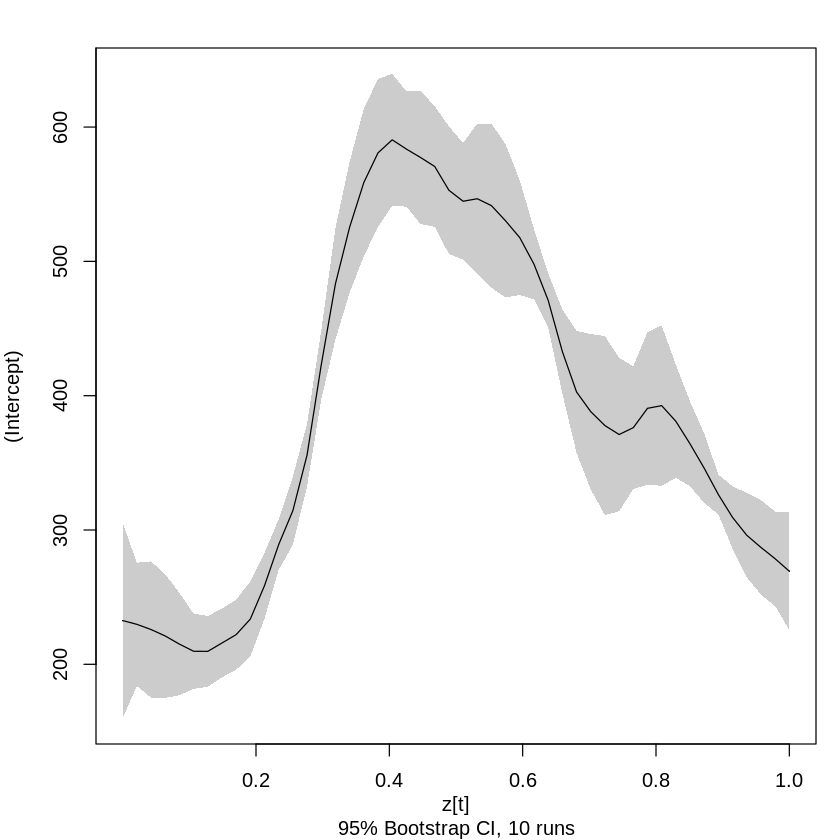

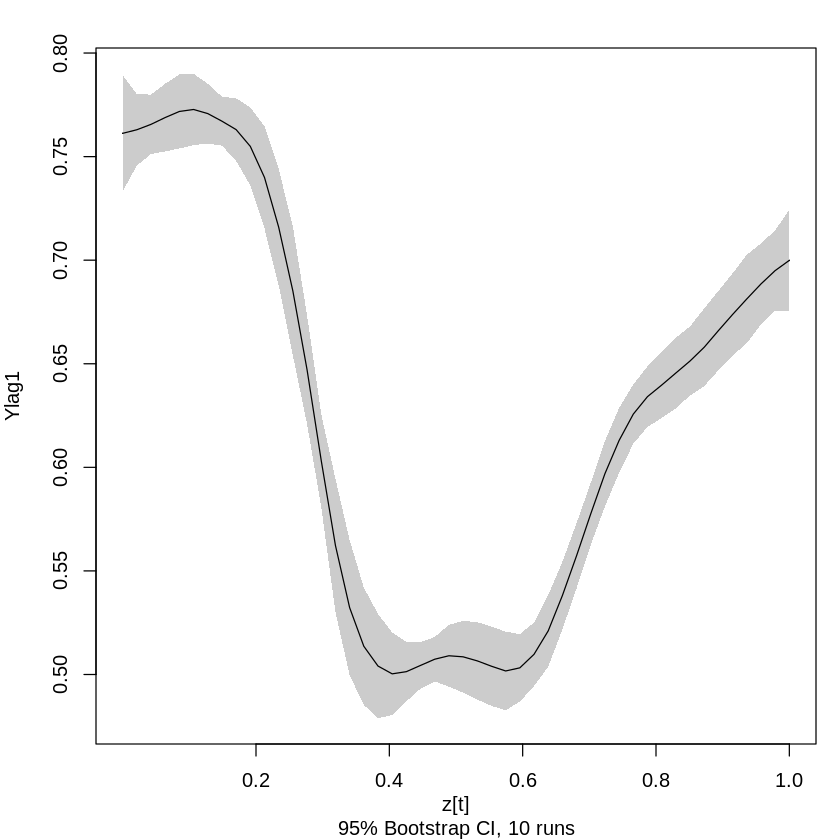

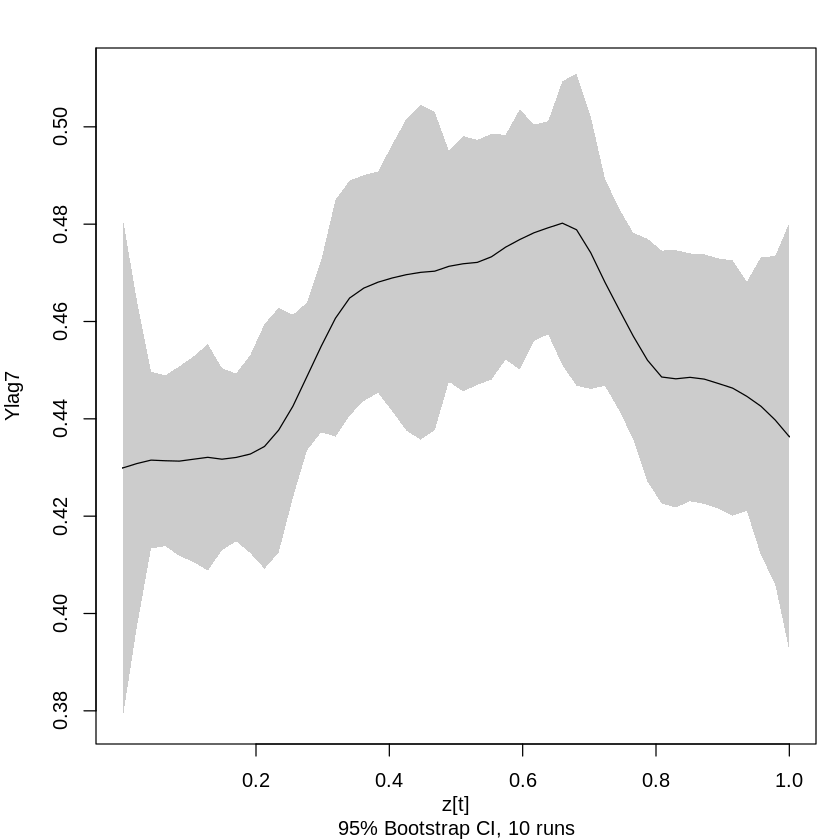

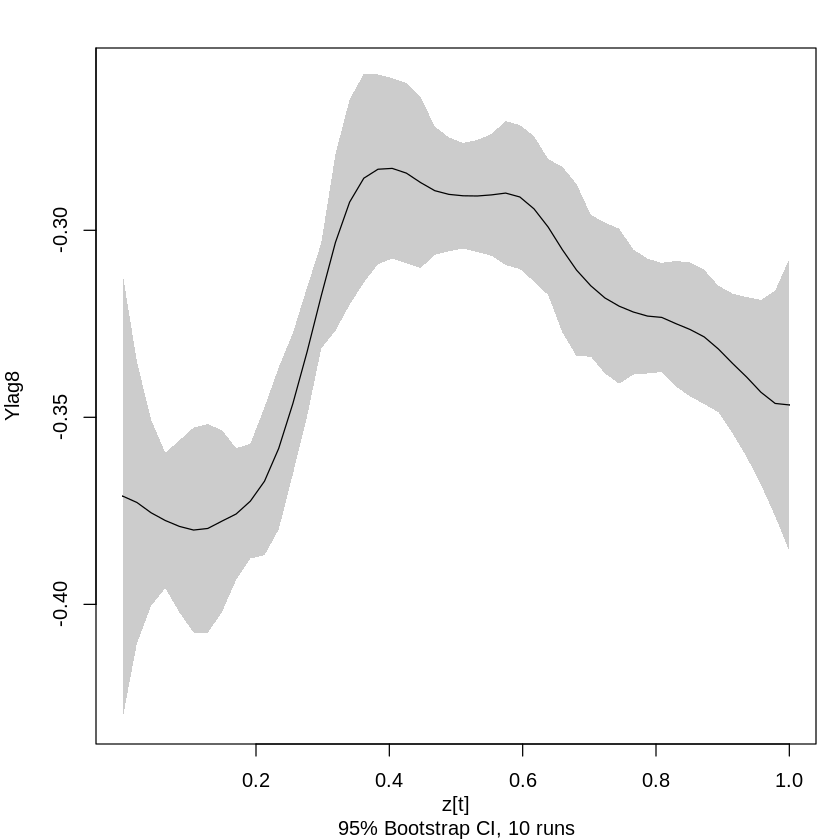

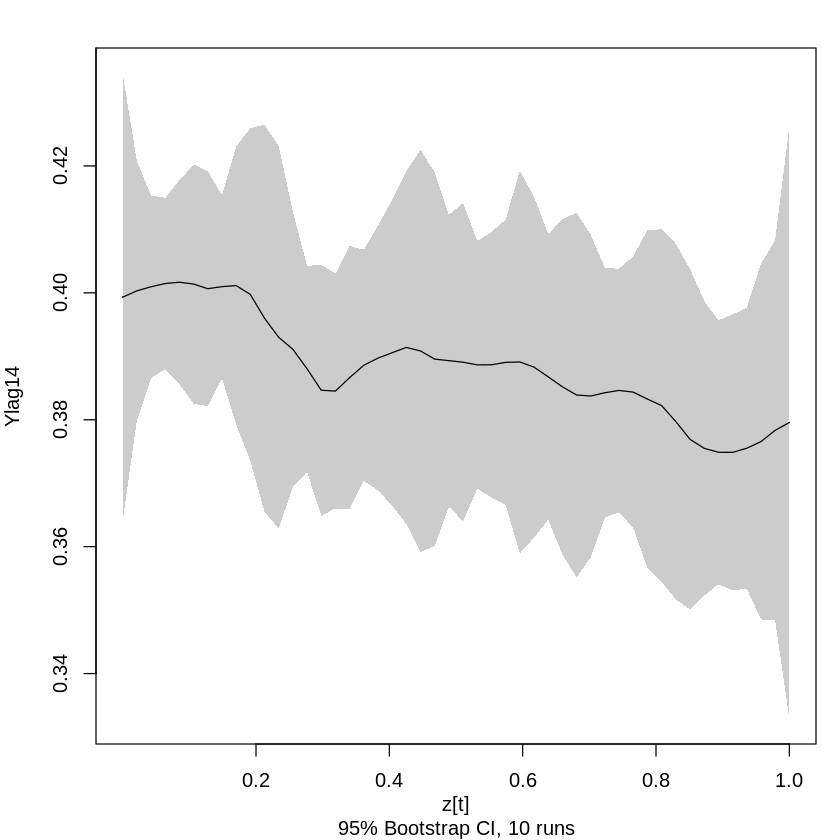

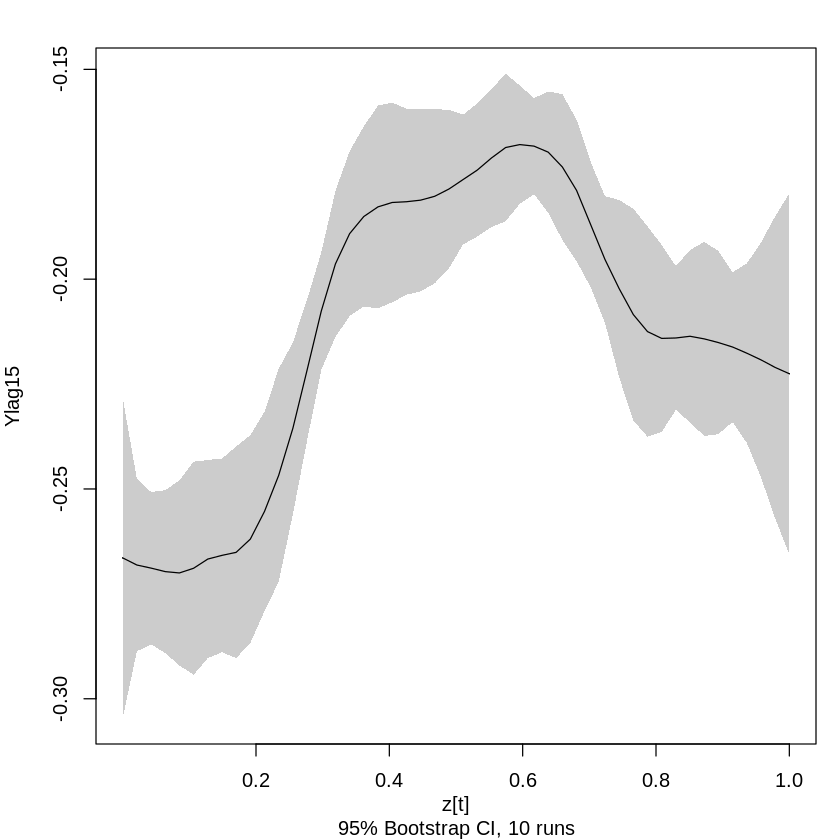

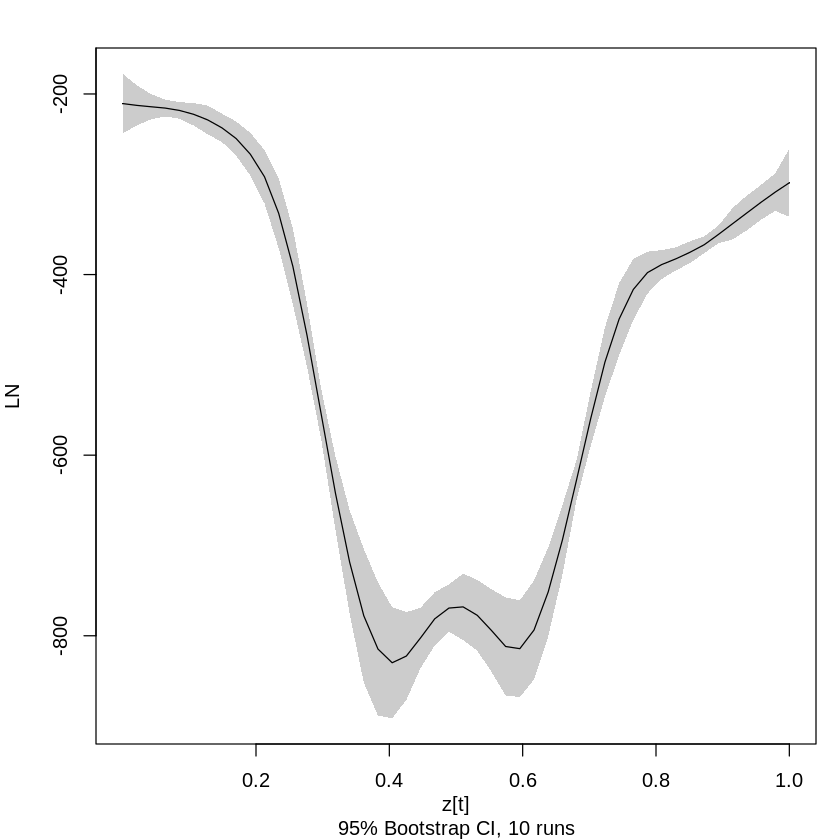

In [ ]:
plot(CI95_M1)

**Diagnostics**

In [ ]:
# ----- RESIDUAL -----

t <- slot_scaled
day <- data$Tanggal[721:87648]

# Residual & fitted (change Model_tvLM6 to Model_tvLM1)
res_m1 <- Model_tvLM1$residuals
fit_m1 <- Model_tvLM1$fitted

resid1 <- data.frame(t = t, day = day, resid = res_m1)
fitted1 <- data.frame(t = t, day = day, fit = fit_m1)

resid1.mean <- resid1 %>% group_by(t) %>% summarize(mean = mean(resid))

# Matrix & functional data
resid1.mat <- spread(data = resid1, key = day, value = resid) %>% dplyr::select(-t)
fitted1.mat <- spread(data = fitted1, key = day, value = fit) %>% dplyr::select(-t)

BSpline <- function(nbasis){create.bspline.basis(c(1,48), nbasis)}

resid1.fd <- smooth.basis(y = as.matrix(resid1.mat), fdParobj = BSpline(7))
fitted1.fd <- smooth.basis(y = as.matrix(fitted1.mat), fdParobj = BSpline(7))

# =========================
# COVARIATES
# =========================

covariate_fd_m1   <- list()
covariate_pca_m1  <- list()
covariate_scores_m1 <- list()
covariate_eigen_m1  <- list()

for(i in 2:7){
  cov_temp <- data.frame(t, day, Model_tvLM1$x[,i])
  names(cov_temp) <- c("t","day","covariate")

  cov_mat <- spread(data = cov_temp, key = day, value = covariate) %>% dplyr::select(-t)
  cov_fd  <- smooth.basis(y = as.matrix(cov_mat), fdParobj = BSpline(7))
  cov_pca <- pca.fd(cov_fd$fd, nharm = 6)

  covariate_fd_m1[[i]]     <- cov_fd
  covariate_pca_m1[[i]]    <- cov_pca
  covariate_scores_m1[[i]] <- cov_pca$scores[,1:2]
  covariate_eigen_m1[[i]]  <- cov_pca$values[1:2]
}

# =========================
# PCA Residual
# =========================

resid.pca_m1 <- pca.fd(resid1.fd$fd, nharm = 6)
resid.pca.scores_m1 <- resid.pca_m1$scores[,1:2]

m1.eigen.resid <- resid.pca_m1$values[1:2]

m1.resid.scores <- data.frame(
  k = rep(1:2, each = 1811),
  resid = matrix(resid.pca.scores_m1, ncol = 1)
)

# =========================
# SCORE & TEST FUNCTION
# =========================
residTest <- function(scores, eigen.resid, eigen.covariate, bin, M = 1000) {
  set.seed(123)
  K <- scores %>% distinct(k) %>% pull()
  n <- scores %>% filter(k==1) %>% count() %>% pull()
  J <- names(scores %>% dplyr::select(-k,-resid))

  Tk <- c()
  for (i in K){
    Tj <- c()
    for (j in J) {
      tj <- scores %>%
        dplyr::select(k, resid) %>%
        mutate(covariate = as.matrix(scores[j])) %>%
        filter(k==i) %>%
        mutate_if(is.matrix, as.numeric) %>%
        arrange(covariate) %>%
        mutate(bin=bin) %>%
        group_by(bin) %>%
        summarize(mean = mean(resid)) %>%
        summarize(var = var(mean))

      Tj <- c(Tj, tj$var)
    }
    Tk <- c(Tk, weighted.mean(Tj, eigen.covariate))
  }

  T0 <- weighted.mean(Tk, eigen.resid)

  T0m <- c()
  for (j in 1:M) {
    Tm <- c()
    for (i in K) {
      tm <- scores %>%
        filter(k==i) %>%
        dplyr::select(resid) %>%
        sample_n(n) %>%
        mutate(bin=bin) %>%
        group_by(bin) %>%
        summarize(mean = mean(resid)) %>%
        summarize(var = var(mean))

      Tm <- c(Tm, tm$var)
    }
    T0m <- c(T0m, weighted.mean(Tm, eigen.resid))
  }

  pvalue <- mean(T0m >= T0)

  list(stat = T0, dist = T0m, pvalue = pvalue)
}

# =========================
# BIN DEFINITIONS
# =========================

bin1 <- c(rep(1:15, each=120), rep(15, each=11))
bin2 <- c(rep(1:30, each=60), rep(31, each=11))
bin3 <- c(rep(1:60, each=30), rep(61, each=11))

# List of bins for looping
bins_list <- list(bin1 = bin1, bin2 = bin2, bin3 = bin3)

# =========================
# TEST ALL LAG FOR ALL BINS
# =========================

results_m1 <- list()

for(b in names(bins_list)) {
  cat("\n========== BIN:", b, "==========\n")
  results_m1[[b]] <- list()

  for(i in 2:7){
    cov_scores <- covariate_scores_m1[[i]]
    colnames(cov_scores) <- c("PC1","PC2")

    scores_temp <- cbind(m1.resid.scores, cov_scores)

    results_m1[[b]][[i]] <- residTest(
      scores_temp,
      m1.eigen.resid,
      covariate_eigen_m1[[i]],
      bins_list[[b]]
    )

    cat("Cov", i-1,
        "Stat:", results_m1[[b]][[i]]$stat,
        "P-value:", results_m1[[b]][[i]]$pvalue, "\n")
  }
}


========== BIN: bin1 ==========
Cov 1 Stat: 25131.08 P-value: 0.003 
Cov 2 Stat: 22588.72 P-value: 0.005 
Cov 3 Stat: 24838.86 P-value: 0.003 
Cov 4 Stat: 17906.9 P-value: 0.029 
Cov 5 Stat: 18656.33 P-value: 0.023 
Cov 6 Stat: 51181.29 P-value: 0 

========== BIN: bin2 ==========
Cov 1 Stat: 42768.53 P-value: 0.013 
Cov 2 Stat: 42390.96 P-value: 0.013 
Cov 3 Stat: 40133.2 P-value: 0.023 
Cov 4 Stat: 47379.67 P-value: 0.008 
Cov 5 Stat: 26202.54 P-value: 0.261 
Cov 6 Stat: 70520.82 P-value: 0 

========== BIN: bin3 ==========
Cov 1 Stat: 59998.86 P-value: 0.013 
Cov 2 Stat: 62929.08 P-value: 0.007 
Cov 3 Stat: 60630.98 P-value: 0.011 
Cov 4 Stat: 79590.09 P-value: 0 
Cov 5 Stat: 55665.14 P-value: 0.033 
Cov 6 Stat: 98344.02 P-value: 0 


t,mean
<dbl>,<dbl>
0.00000000,0.075503333
0.02127660,-0.177316741
0.04255319,-0.004535031
0.06382979,-0.549600601
0.08510638,-1.107032340
0.10638298,-2.107342503
0.12765957,-2.305814586
0.14893617,-1.296692164
0.17021277,1.681804977


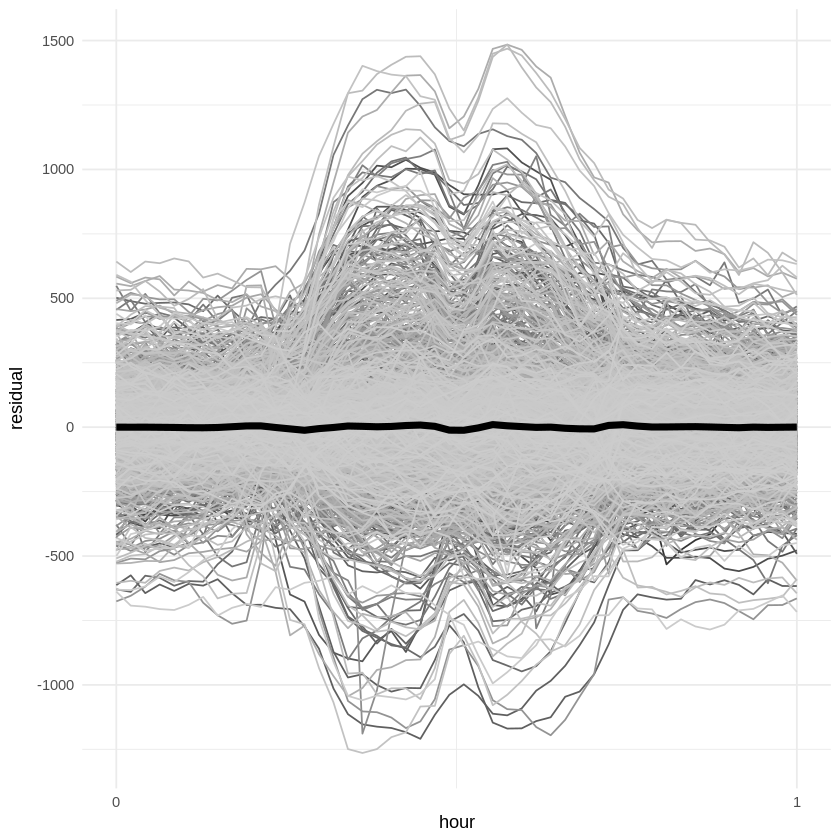

In [ ]:
resid1.mean

p1 <- ggplot(resid1, aes(x = t, y = resid)) +
      geom_line(aes(group = as.factor(day), color = as.factor(day))) + labs(x="hour", y="residual") +
      theme_minimal() + theme(legend.position = "none") + scale_color_grey() + scale_x_continuous(breaks = 0:23, labels = 0:23)
p1 <- p1 + geom_line(data = resid1.mean, aes(x = t, y = mean), size = 2)

p1

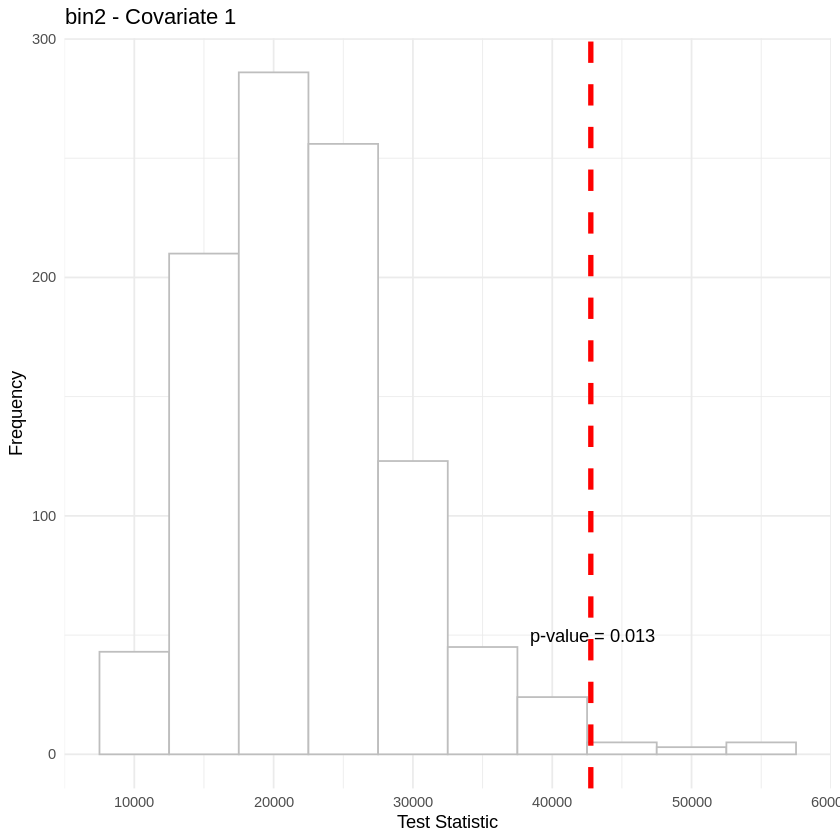

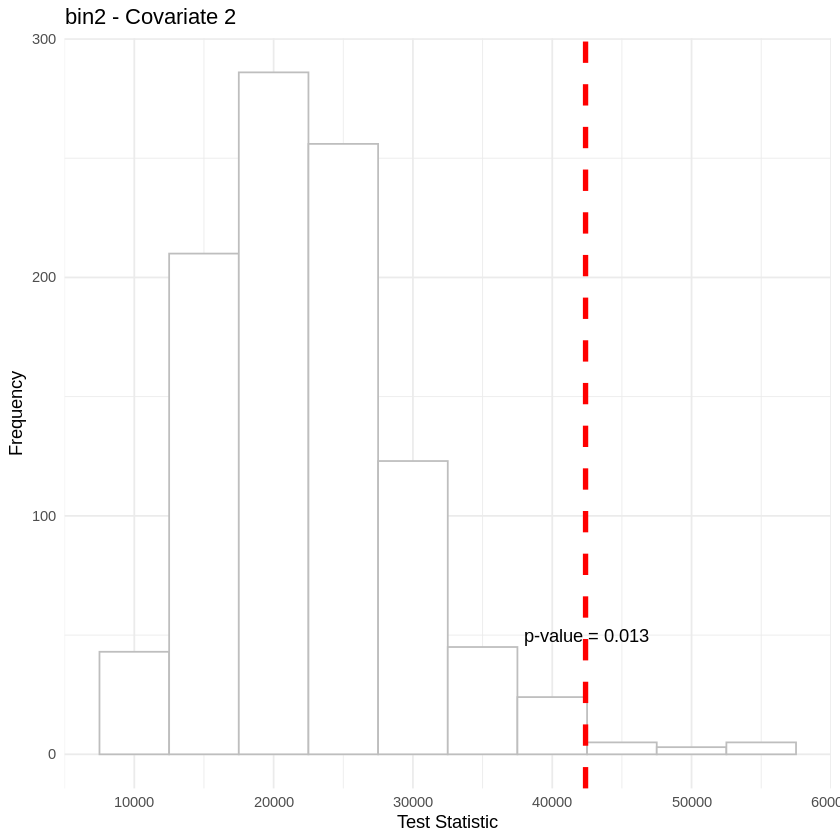

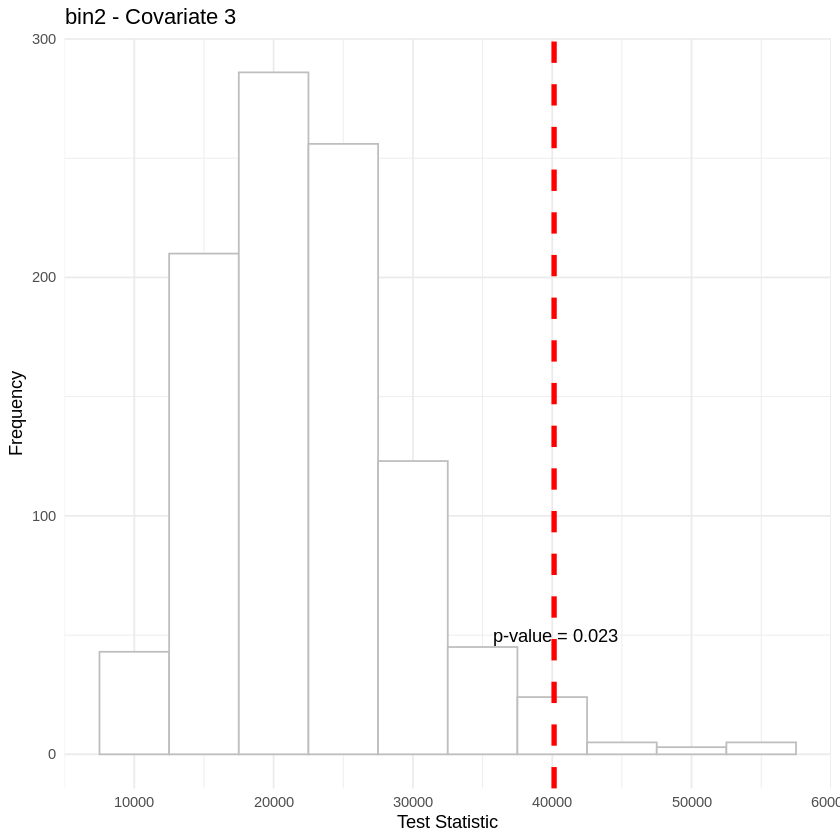

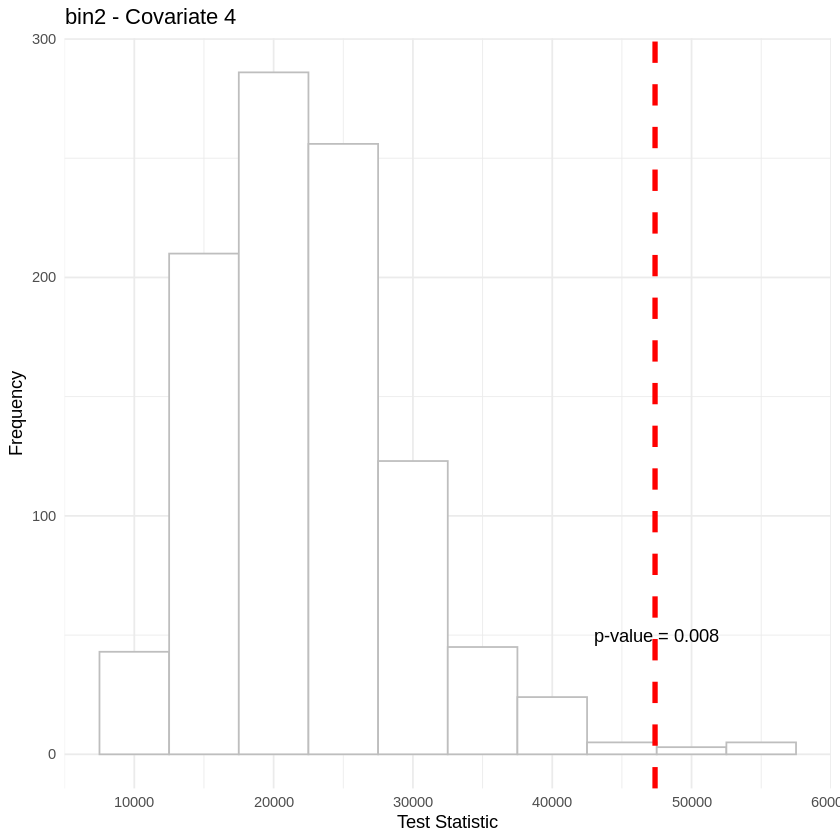

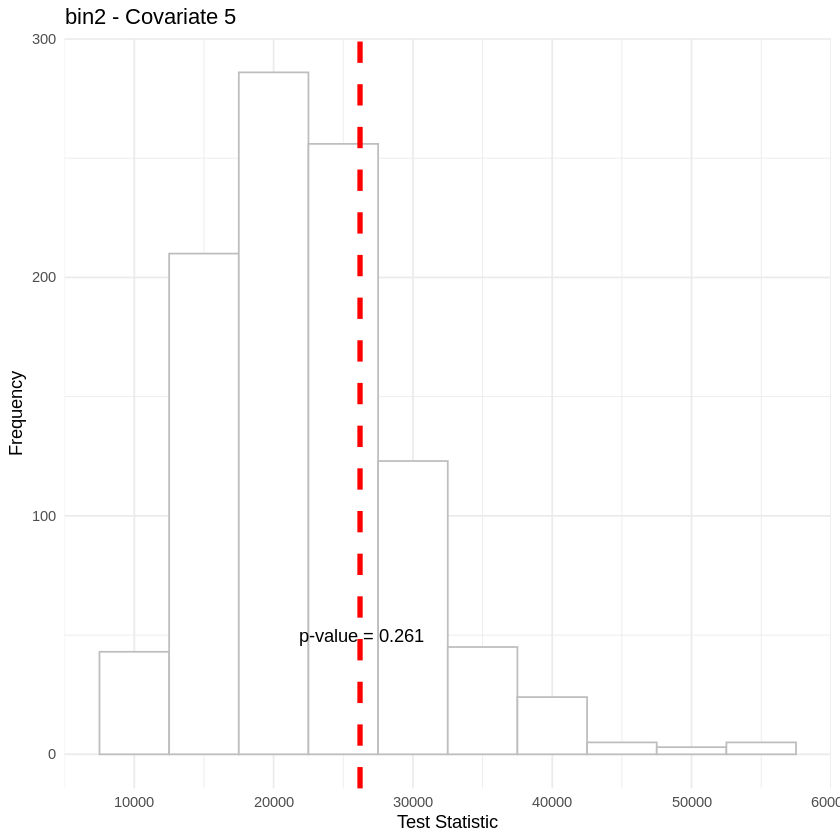

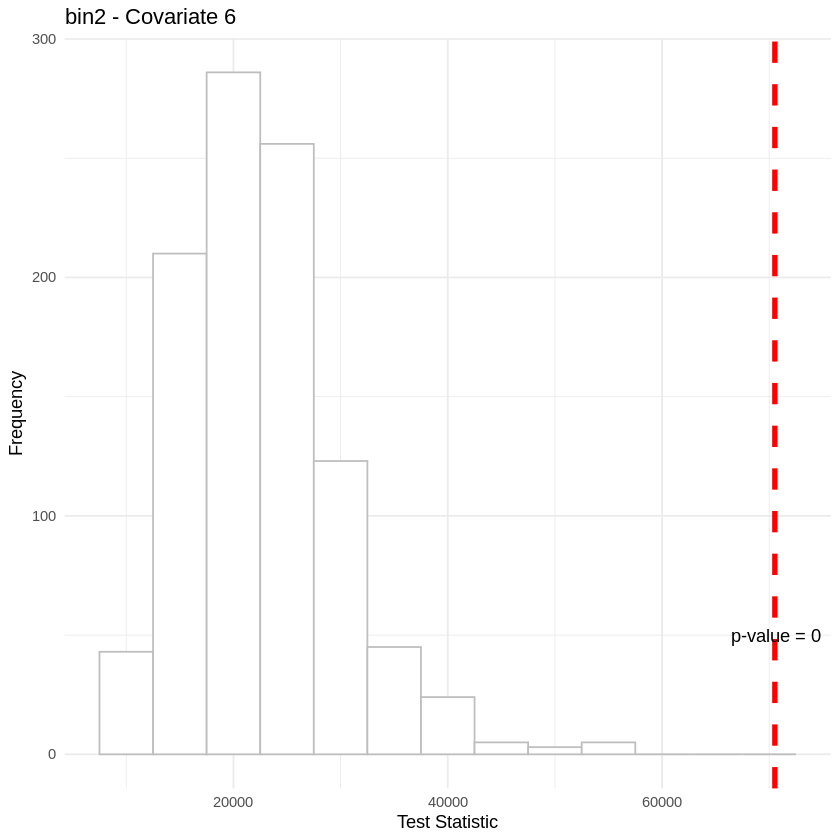

In [ ]:
# Parameter yang bisa Anda atur
bin_choice <- "bin2"      # Ganti sesuai kebutuhan: "bin1", "bin2", "bin3"
cov_range <- 2:7           # Ganti sesuai range covariate yang diinginkan

# Buat dan tampilkan semua plot dalam satu baris
invisible(lapply(cov_range, function(i) {
  bin_data <- results_m1[[bin_choice]][[i]]
  p <- ggplot(data.frame(dist = bin_data$dist), aes(x = dist)) +
    geom_histogram(color = "grey", fill = "white", binwidth = 5000) +
    geom_vline(xintercept = bin_data$stat,
               linetype = "dashed", color = "red", linewidth = 1.5) +
    xlab("Test Statistic") + ylab("Frequency") +
    ggtitle(paste(bin_choice, "- Covariate", i-1)) +
    annotate("text", x = bin_data$stat + 100, y = 50,
             label = paste("p-value =", bin_data$pvalue)) +
    theme_minimal()
  print(p)
}))

**Out of Sampel Accuracy**

[1] 177.3756

[1] 2.72818

[1] 2.764905

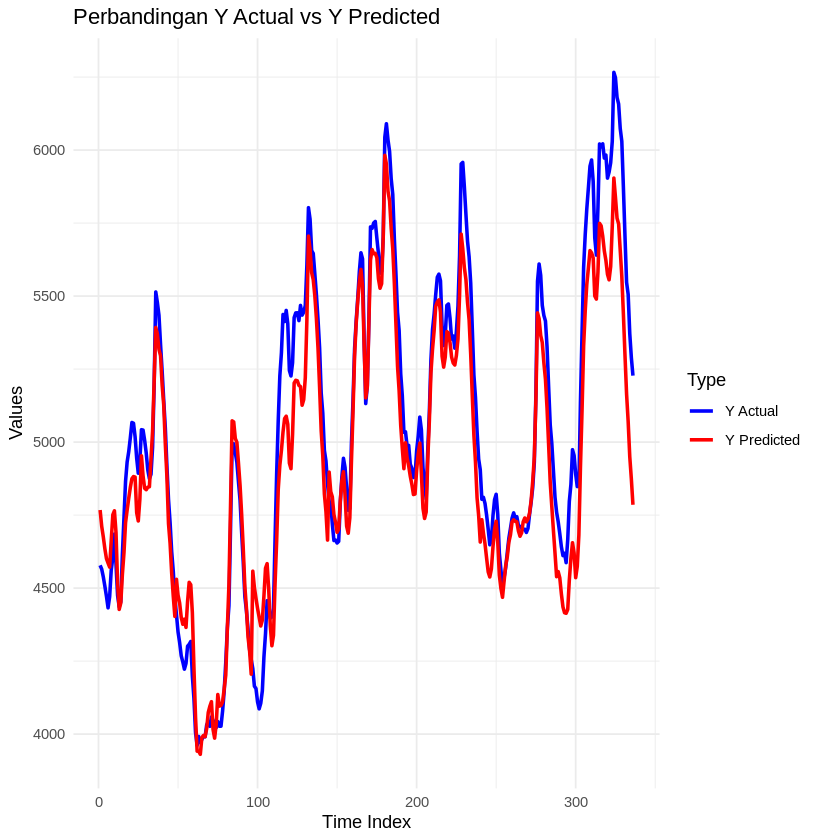

In [ ]:
#coef
BetaI <- Model_tvLM1$coefficient[1:48,1]
Beta1 <- Model_tvLM1$coefficient[1:48,2]
Beta7 <- Model_tvLM1$coefficient[1:48,3]
Beta8 <- Model_tvLM1$coefficient[1:48,4]
Beta14 <- Model_tvLM1$coefficient[1:48,5]
Beta15 <- Model_tvLM1$coefficient[1:48,6]
BetaLN <- Model_tvLM1$coefficient[1:48,7]

#lag os
Ylag1_OS <- data$Y[87601:87648]
Ylag2_OS <- data$Y[87553:87600]
Ylag3_OS <- data$Y[87505:87552]
Ylag4_OS <- data$Y[87457:87504]
Ylag5_OS <- data$Y[87409:87456]
Ylag6_OS <- data$Y[87361:87408]
Ylag7_OS <- data$Y[87313:87360]
Ylag8_OS <- data$Y[87265:87312]
Ylag9_OS <- data$Y[87217:87264]
Ylag10_OS <- data$Y[87169:87216]
Ylag11_OS <- data$Y[87121:87168]
Ylag12_OS <- data$Y[87073:87120]
Ylag13_OS <- data$Y[87025:87072]
Ylag14_OS <- data$Y[86977:87024]
Ylag15_OS <- data$Y[86929:86976]

YhatD1 <- BetaI + Beta1*Ylag1_OS + Beta7*Ylag7_OS + Beta8*Ylag8_OS + Beta14*Ylag14_OS + Beta15*Ylag15_OS + BetaLN*1
YhatD2 <- BetaI + Beta1*YhatD1 + Beta7*Ylag6_OS + Beta8*Ylag7_OS + Beta14*Ylag13_OS + Beta15*Ylag14_OS + BetaLN*1
YhatD3 <- BetaI + Beta1*YhatD2 + Beta7*Ylag5_OS + Beta8*Ylag6_OS + Beta14*Ylag12_OS + Beta15*Ylag13_OS
YhatD4 <- BetaI + Beta1*YhatD3 + Beta7*Ylag4_OS + Beta8*Ylag5_OS + Beta14*Ylag11_OS + Beta15*Ylag12_OS
YhatD5 <- BetaI + Beta1*YhatD4 + Beta7*Ylag3_OS + Beta8*Ylag4_OS + Beta14*Ylag10_OS + Beta15*Ylag11_OS
YhatD6 <- BetaI + Beta1*YhatD5 + Beta7*Ylag2_OS + Beta8*Ylag3_OS + Beta14*Ylag9_OS + Beta15*Ylag10_OS
YhatD7 <- BetaI + Beta1*YhatD6 + Beta7*Ylag1_OS + Beta8*Ylag2_OS + Beta14*Ylag8_OS + Beta15*Ylag9_OS

#Plot
Yact <- data$Y[87649:87984]
Yhat <- c(YhatD1,YhatD2,YhatD3,YhatD4,YhatD5,YhatD6,YhatD7)

df_plot <- data.frame(
  Time = rep(1:336, 2),
  Values = c(Yact, Yhat),
  Type = rep(c("Y Actual", "Y Predicted"), each = length(Yact))
)

ggplot(df_plot, aes(x = Time, y = Values, color = Type)) +
  geom_line(size = 1) +
  labs(title = "Perbandingan Y Actual vs Y Predicted",
       x = "Time Index", y = "Values") +
  scale_color_manual(values = c("blue", "red")) +
  theme_minimal()

#extract residual
write.csv(df_plot,"residual TVLM[1,7,8,14,15] + LN tk[EPA] bw[0.085].csv")

#Evalution Matrices
RMSE <- sqrt(sum((Yact-Yhat)^2)/336)
MAPE <- sum(abs((Yact-Yhat)/Yact))/336*100
SMAPE <- sum(abs(Yact-Yhat)/((abs(Yact)+abs(Yhat))/2))/336*100

RMSE;MAPE;SMAPE

In [ ]:
# Calculate daily and overall accuracy metrics
Yact_matrix <- matrix(Yact, nrow = 48, ncol = 7, byrow = FALSE)  # 48 days x 7 horizons
Yhat_matrix <- matrix(Yhat, nrow = 48, ncol = 7, byrow = FALSE)

# Initialize vectors for daily metrics
RMSE_daily <- numeric(7)
MAPE_daily <- numeric(7)
SMAPE_daily <- numeric(7)

# Calculate metrics for each day (horizon)
for(h in 1:7) {
  RMSE_daily[h] <- sqrt(mean((Yact_matrix[,h] - Yhat_matrix[,h])^2))
  MAPE_daily[h] <- mean(abs((Yact_matrix[,h] - Yhat_matrix[,h]) / Yact_matrix[,h])) * 100
  SMAPE_daily[h] <- mean(abs(Yact_matrix[,h] - Yhat_matrix[,h]) / ((abs(Yact_matrix[,h]) + abs(Yhat_matrix[,h]))/2)) * 100
}

# Overall metrics for all 7 days combined
RMSE_overall <- sqrt(mean((Yact - Yhat)^2))
MAPE_overall <- mean(abs((Yact - Yhat) / Yact)) * 100
SMAPE_overall <- mean(abs(Yact - Yhat) / ((abs(Yact) + abs(Yhat))/2)) * 100

# Results
cat("===== DAILY ACCURACY METRICS (per forecasting horizon) =====\n")
for(h in 1:7) {
  cat(sprintf("Day/Horizon %d: RMSE = %.4f, MAPE = %.2f%%, SMAPE = %.2f%%\n",
              h, RMSE_daily[h], MAPE_daily[h], SMAPE_daily[h]))
}

cat("\n===== OVERALL ACCURACY METRICS (all 7 days combined) =====\n")
cat(sprintf("RMSE = %.4f\n", RMSE_overall))
cat(sprintf("MAPE = %.2f%%\n", MAPE_overall))
cat(sprintf("SMAPE = %.2f%%\n", SMAPE_overall))

===== DAILY ACCURACY METRICS (per forecasting horizon) =====
Day/Horizon 1: RMSE = 116.1368, MAPE = 2.14%, SMAPE = 2.14%
Day/Horizon 2: RMSE = 89.0502, MAPE = 1.61%, SMAPE = 1.60%
Day/Horizon 3: RMSE = 236.0452, MAPE = 4.36%, SMAPE = 4.39%
Day/Horizon 4: RMSE = 102.4203, MAPE = 1.54%, SMAPE = 1.55%
Day/Horizon 5: RMSE = 140.8345, MAPE = 2.21%, SMAPE = 2.25%
Day/Horizon 6: RMSE = 114.8773, MAPE = 1.78%, SMAPE = 1.80%
Day/Horizon 7: RMSE = 315.5610, MAPE = 5.46%, SMAPE = 5.63%

===== OVERALL ACCURACY METRICS (all 7 days combined) =====
RMSE = 177.3756
MAPE = 2.73%
SMAPE = 2.76%
